# 10c — Trend-aware + empirical-p99 policy

**Goal.** Fix the 5 regression lanes from `10b` without over-ordering on declining SKUs.

**The two changes vs the default policy:**

1. **Trend detection.** Compute `recent_mean / full_mean` on weekly outflow (recent = last 26 weeks). If ratio < 0.7 → `declining`. Use the last `max(26, 2·LT)` weeks as the **effective window** for run_rate + σ. If ratio > 1.3 → `growing` (stay on full history for conservatism). Else → `stable`.
2. **Empirical p99 safety stock.** On the effective window, compute the rolling LT-week sum of outflow, take the p99, subtract `run_rate · LT`. This is how far above the mean demand-during-LT has empirically gotten. Use `SS = max(Z·σ·√LT, p99_lt − run_rate·LT)` — whichever is bigger. For fat-tailed lanes the empirical term dominates; for well-behaved lanes the analytic Z·σ·√LT still wins.

**Why this should help the 5 failing lanes:**

All 5 are visually declining in actual on_hand over 2023→2026, yet they have bursty demand (burst_mult ≥ 2). The default policy uses full-history σ, which under-weights recent bursts relative to a normal-distribution assumption. The new policy:
- Bursts-in-window → empirical p99 inflates SS → reorder point climbs → trigger earlier → PO arrives in time.
- Declining trend → run_rate shrinks → total order qty shrinks → less overshoot.

**Why it should NOT break the stable lanes:**

Trend-stable + burst-quiet lanes see `empirical p99 ≈ Z·σ·√LT`, so SS is unchanged. Only fat-tailed or regime-shifting lanes move.

**Scope.** Re-simulate the 5 failing lanes with the new policy; plot side-by-side with `10b` results. Full 116-lane sweep at the end to check we don't regress stable lanes.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'pipeline' else Path.cwd()
ART  = ROOT / 'pipeline' / 'artifacts'
FIG  = ART / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.reorder import FORWARD_COVER_WEEKS, _round_up_case

FAIL_LANES = [
    ('F-04118', 'NJ'), ('F-04130', 'LA'), ('F-04001', 'NJ'),
    ('F-04114', 'LA'), ('F-76010', 'LA'),
]

# Reused inputs.
alerts_wf  = pd.read_parquet(ART / 'backtest_alerts.parquet')
inv_weekly = pd.read_parquet(ART / 'inv_weekly.parquet')
sales      = pd.read_parquet(ART / 'sales.parquet')

DC_MAP = {'1': 'SF', '2': 'NJ', '3': 'LA'}
sales['QTY_BASE']   = sales['QUANTITY_adj'].astype(float) * sales['QTYBSUOM'].fillna(1).astype(float)
sales['DC']         = sales['LOCNCODE'].astype(str).map(DC_MAP)
sales               = sales.dropna(subset=['DC'])
sales['week_start'] = pd.to_datetime(sales['DOCDATE']).dt.to_period('W-SUN').dt.start_time
outflow_wk = (sales.groupby(['ITEMNMBR', 'DC', 'week_start'], as_index=False)['QTY_BASE']
                   .sum()
                   .rename(columns={'QTY_BASE': 'outflow'}))

alerts_wf['as_of_week']     = pd.to_datetime(alerts_wf['as_of_week'])
inv_weekly['week_start']    = pd.to_datetime(inv_weekly['week_start'])
outflow_wk['week_start']    = pd.to_datetime(outflow_wk['week_start'])

print(f'alerts_wf : {alerts_wf.shape}  as_of weeks: {alerts_wf.as_of_week.nunique()}')
print(f'outflow_wk: {outflow_wk.shape}  ({outflow_wk.week_start.min().date()} → {outflow_wk.week_start.max().date()})')
print(f'failing lanes: {FAIL_LANES}')

alerts_wf : (7084, 40)  as_of weeks: 34
outflow_wk: (22997, 4)  (2023-01-02 → 2026-04-13)
failing lanes: [('F-04118', 'NJ'), ('F-04130', 'LA'), ('F-04001', 'NJ'), ('F-04114', 'LA'), ('F-76010', 'LA')]


## 1. Trend-aware policy

For a given `(sku, dc, as_of_week)`:

- Slice outflow up to `as_of_week`.
- Detect regime by comparing recent-26-wk mean to full-history mean.
- Pick effective window: full history for stable/growing, last `max(26, 2·LT)` weeks for declining.
- Compute `run_rate = mean(effective)`, `σ = std(effective)`.
- Compute `p99_lt = quantile(rolling(LT).sum(effective), 0.99)`.
- `SS = max(Z·σ·√LT, p99_lt − run_rate·LT)`.
- `ROP = run_rate·LT + SS`.

Z is carried over from the original alert row (tier-based, set in `src/reorder.py`).

In [2]:
RECENT_WK = 26
TREND_DECLINING = 0.70
TREND_GROWING   = 1.30

def trend_aware_policy(outflow_series: pd.Series, lead_time_wk: float, z: float,
                       recent_wk: int = RECENT_WK) -> dict:
    """outflow_series: indexed by week_start, sorted asc, possibly with gaps (zeros filled)."""
    s = outflow_series.astype(float)
    lt = max(int(round(float(lead_time_wk) if pd.notna(lead_time_wk) else 13.0)), 1)

    if len(s) == 0:
        return dict(regime='no_data', run_rate=0.0, std=0.0, ss=0.0, rop=0.0,
                    ss_normal=0.0, ss_empirical=0.0, p99_lt=np.nan,
                    full_mean=0.0, recent_mean=0.0, trend_ratio=np.nan,
                    n_eff=0, z=z, lt=lt)

    full_mean = float(s.mean())
    tail = s.tail(recent_wk)
    recent_mean = float(tail.mean()) if len(tail) else full_mean
    trend_ratio = recent_mean / full_mean if full_mean > 0 else 1.0

    if trend_ratio < TREND_DECLINING and len(s) >= recent_wk:
        eff_len = max(recent_wk, 2 * lt)
        effective = s.tail(eff_len)
        regime = 'declining'
    elif trend_ratio > TREND_GROWING and len(s) >= recent_wk:
        effective = s.tail(max(recent_wk, 2 * lt))
        regime = 'growing'
    else:
        effective = s
        regime = 'stable'

    run_rate = float(effective.mean())
    std      = float(effective.std(ddof=0)) if len(effective) > 1 else 0.0

    if len(effective) >= lt:
        lt_sums = effective.rolling(lt).sum().dropna()
        p99_lt  = float(lt_sums.quantile(0.99)) if len(lt_sums) else np.nan
    else:
        p99_lt = np.nan

    ss_normal    = z * std * np.sqrt(lt)
    ss_empirical = max(0.0, (p99_lt - run_rate * lt)) if pd.notna(p99_lt) else 0.0
    ss  = float(max(ss_normal, ss_empirical))
    rop = run_rate * lt + ss

    return dict(regime=regime, run_rate=run_rate, std=std, ss=ss, rop=rop,
                ss_normal=ss_normal, ss_empirical=ss_empirical, p99_lt=p99_lt,
                full_mean=full_mean, recent_mean=recent_mean, trend_ratio=trend_ratio,
                n_eff=int(len(effective)), z=float(z), lt=lt)


def lane_outflow_series(sku: str, dc: str, upto: pd.Timestamp) -> pd.Series:
    """Weekly outflow for (sku, dc), indexed by week, zero-filled from first observed week to upto.

    Grid uses freq='7D' anchored on the first observed week — aligns with
    whatever day-of-week the existing data uses (Monday in our case, because
    upstream built week_start via to_period('W-SUN').start_time).
    """
    lane = outflow_wk[(outflow_wk.ITEMNMBR == sku) & (outflow_wk.DC == dc) &
                      (outflow_wk.week_start < upto)]
    if lane.empty:
        return pd.Series(dtype=float)
    s = lane.set_index('week_start')['outflow'].astype(float).sort_index()
    start = s.index.min()
    grid  = pd.date_range(start, upto - pd.Timedelta(days=1), freq='7D')
    return s.reindex(grid, fill_value=0.0)


# Quick sanity: show regime + policy for each failing lane at the final as-of week.
final_asof = alerts_wf.as_of_week.max()
print(f'=== Policy at final as-of week ({final_asof.date()}) ===\n')
for sku, dc in FAIL_LANES:
    row = alerts_wf[(alerts_wf.ITEMNMBR == sku) & (alerts_wf.DC == dc) &
                    (alerts_wf.as_of_week == final_asof)]
    if row.empty:
        print(f'{sku} {dc}: no alert at final as-of'); continue
    r    = row.iloc[0]
    z    = float(r['z_applied']) if pd.notna(r['z_applied']) else 1.28
    lt   = float(r['lead_time_wk']) if pd.notna(r['lead_time_wk']) else 13.0
    s    = lane_outflow_series(sku, dc, final_asof)
    pol  = trend_aware_policy(s, lt, z)
    old_ss  = float(r['safety_stock'])
    old_rop = float(r['reorder_point'])
    old_rr  = float(r['run_rate_wk'])
    print(f'{sku} {dc} [{pol["regime"]:>9}]  '
          f'rr {old_rr:>7,.0f}→{pol["run_rate"]:>7,.0f}  '
          f'ss {old_ss:>8,.0f}→{pol["ss"]:>8,.0f}  '
          f'rop {old_rop:>8,.0f}→{pol["rop"]:>8,.0f}  '
          f'trend {pol["trend_ratio"]:.2f}  '
          f'p99_lt {pol["p99_lt"]:>8,.0f}  '
          f'ss_emp/ss_norm {pol["ss_empirical"]:,.0f}/{pol["ss_normal"]:,.0f}  '
          f'n_eff={pol["n_eff"]}')

=== Policy at final as-of week (2025-10-13) ===

F-04118 NJ [  growing]  rr   1,739→  5,980  ss   16,235→  23,188  rop   59,703→ 172,678  trend 1.39  p99_lt  172,678  ss_emp/ss_norm 23,188/19,391  n_eff=50
F-04130 LA [  growing]  rr   1,632→  5,559  ss   20,338→  23,355  rop   57,646→ 151,207  trend 1.66  p99_lt  150,757  ss_emp/ss_norm 22,905/23,355  n_eff=46
F-04001 NJ [  growing]  rr     167→  2,152  ss    1,546→  20,134  rop    4,762→  61,028  trend 1.58  p99_lt   58,872  ss_emp/ss_norm 17,978/20,134  n_eff=38
F-04114 LA [  growing]  rr   1,253→  3,103  ss   13,402→  14,907  rop   40,957→  83,182  trend 1.49  p99_lt   77,437  ss_emp/ss_norm 9,162/14,907  n_eff=44
F-76010 LA [   stable]  rr     279→    437  ss    2,420→  10,839  rop    7,308→  18,711  trend 0.80  p99_lt   18,711  ss_emp/ss_norm 10,839/3,111  n_eff=145


## 2. Build new alerts frame

Rewrite `run_rate_wk` and `reorder_point` on every `(lane, as_of_week)` row using the trend-aware policy. Keep `lead_time_wk` and `case_pack` untouched (those come from PO history / item master). The sim keys on `reorder_point` for triggering, `run_rate_wk` for forward cover, and `case_pack` for rounding — swapping just these columns is sufficient.

In [3]:
def build_trend_alerts(alerts_old: pd.DataFrame, lanes=None) -> pd.DataFrame:
    """Return a copy of alerts_old with run_rate_wk, safety_stock, reorder_point,
    plus provenance columns (regime, trend_ratio, p99_lt, ss_normal, ss_empirical)
    overwritten for the given lanes (default: all lanes in alerts_old).
    """
    out = alerts_old.copy()
    if lanes is not None:
        lane_set = {(s, d) for s, d in lanes}
        mask = out[['ITEMNMBR', 'DC']].apply(tuple, axis=1).isin(lane_set)
    else:
        mask = pd.Series(True, index=out.index)

    # Provenance
    for col in ['regime', 'trend_ratio', 'p99_lt', 'ss_normal', 'ss_empirical']:
        if col not in out.columns:
            out[col] = np.nan if col != 'regime' else ''

    rows_touched = 0
    for i, r in out.loc[mask].iterrows():
        sku = r['ITEMNMBR']; dc = r['DC']; asof = r['as_of_week']
        z = float(r['z_applied']) if pd.notna(r['z_applied']) else 1.28
        lt = float(r['lead_time_wk']) if pd.notna(r['lead_time_wk']) else 13.0
        s = lane_outflow_series(sku, dc, asof)
        pol = trend_aware_policy(s, lt, z)
        out.at[i, 'run_rate_wk']   = pol['run_rate']
        out.at[i, 'std_wk']        = pol['std']
        out.at[i, 'safety_stock']  = pol['ss']
        out.at[i, 'reorder_point'] = pol['rop']
        out.at[i, 'regime']        = pol['regime']
        out.at[i, 'trend_ratio']   = pol['trend_ratio']
        out.at[i, 'p99_lt']        = pol['p99_lt']
        out.at[i, 'ss_normal']     = pol['ss_normal']
        out.at[i, 'ss_empirical']  = pol['ss_empirical']
        rows_touched += 1

    # refresh reorder_flag (not used by sim, but useful for downstream reporting)
    out.loc[mask, 'reorder_flag'] = (out.loc[mask, 'On Hand'].fillna(0) < out.loc[mask, 'reorder_point']) \
        if 'On Hand' in out.columns else out.loc[mask, 'reorder_flag']

    print(f'rewrote {rows_touched} rows across {sum(mask)} lanes-asof ({mask.sum()} mask hits)')
    return out


alerts_trend_fail = build_trend_alerts(alerts_wf, lanes=FAIL_LANES)

# Regime distribution for the 5 lanes across all as-of weeks
fail_mask = alerts_trend_fail[['ITEMNMBR', 'DC']].apply(tuple, axis=1).isin(set(FAIL_LANES))
print('\nRegime distribution across as-of weeks (5 lanes):')
print(alerts_trend_fail.loc[fail_mask].groupby(['ITEMNMBR', 'DC'])['regime']
      .value_counts().unstack(fill_value=0).to_string())

rewrote 168 rows across 168 lanes-asof (168 mask hits)



Regime distribution across as-of weeks (5 lanes):
regime       declining  growing  stable
ITEMNMBR DC                            
F-04001  NJ          0        6      28
F-04114  LA          0       23      11
F-04118  NJ          0       15      17
F-04130  LA          0       14      20
F-76010  LA          4        6      24


## 3. Counterfactual sim (same engine as `10b`)

Copy of `simulate_followed` from `10_backtest.ipynb` so we can re-run against either alerts frame without importing the notebook.

In [4]:
def simulate_followed(lane_sku, lane_dc, alerts_frame, outflow_wk, inv_weekly):
    alerts_lane = alerts_frame[(alerts_frame.ITEMNMBR == lane_sku) &
                               (alerts_frame.DC == lane_dc)].sort_values('as_of_week')
    if alerts_lane.empty:
        return pd.DataFrame()
    alerts_by_week = {r['as_of_week']: r for _, r in alerts_lane.iterrows()}
    asof_sorted = sorted(alerts_by_week.keys())
    start_week = alerts_lane['as_of_week'].min()

    inv_lane = inv_weekly[(inv_weekly.ITEMNMBR == lane_sku) &
                          (inv_weekly.DC == lane_dc)].sort_values('week_start')
    seed = inv_lane[inv_lane['week_start'] == start_week]
    if seed.empty:
        return pd.DataFrame()
    on_hand = float(seed['on_hand_est'].iloc[0])

    outflow = (outflow_wk[(outflow_wk.ITEMNMBR == lane_sku) &
                          (outflow_wk.DC == lane_dc)]
                         .set_index('week_start')['outflow'])

    weeks = inv_lane[inv_lane['week_start'] >= start_week]['week_start'].tolist()
    po_schedule = {}
    rows = []
    for w in weeks:
        po_arr_qty = po_schedule.pop(w, 0.0)
        on_hand += po_arr_qty
        out = float(outflow.get(w, 0.0))
        on_hand -= out

        current_asof = None
        for aw in asof_sorted:
            if aw <= w:
                current_asof = aw
            else:
                break

        alert_fires = False
        po_qty = 0.0
        if current_asof is not None:
            a = alerts_by_week[current_asof]
            rp = float(a['reorder_point']) if pd.notna(a['reorder_point']) else float('nan')
            rr = float(a['run_rate_wk'])   if pd.notna(a['run_rate_wk'])   else 0.0
            cp = float(a['case_pack'])     if pd.notna(a['case_pack'])     else 1.0
            lead = float(a['lead_time_wk']) if pd.notna(a['lead_time_wk']) else 13.0
            inflight = sum(po_schedule.values())
            inv_position = on_hand + inflight
            if pd.notna(rp) and (inv_position < rp):
                raw = max(0.0, rp + FORWARD_COVER_WEEKS * rr - inv_position)
                po_qty = _round_up_case(raw, cp)
                if po_qty > 0:
                    arr = w + pd.Timedelta(weeks=int(round(lead)))
                    po_schedule[arr] = po_schedule.get(arr, 0.0) + po_qty
                    alert_fires = True
        rows.append({
            'week_start':  w,
            'on_hand_sim': on_hand,
            'outflow':     out,
            'po_arrives':  po_arr_qty,
            'alert_fires': alert_fires,
            'po_ordered':  po_qty,
            'inflight':    sum(po_schedule.values()),
        })
    return pd.DataFrame(rows)


# Re-sim the 5 lanes under BOTH the old policy (alerts_wf) and the new one.
sims_old, sims_new = {}, {}
for sku, dc in FAIL_LANES:
    sims_old[(sku, dc)] = simulate_followed(sku, dc, alerts_wf,         outflow_wk, inv_weekly)
    sims_new[(sku, dc)] = simulate_followed(sku, dc, alerts_trend_fail, outflow_wk, inv_weekly)

for sku, dc in FAIL_LANES:
    o, n = sims_old[(sku, dc)], sims_new[(sku, dc)]
    print(f'{sku} {dc}  old  min={o.on_hand_sim.min():>10,.0f}  final={o.on_hand_sim.iloc[-1]:>10,.0f}  '
          f'n_orders={int(o.alert_fires.sum()):>3d}  tot_ord={o.po_ordered.sum():>12,.0f}  '
          f'wks_neg={int((o.on_hand_sim<0).sum()):>3d}')
    print(f'{sku} {dc}  NEW  min={n.on_hand_sim.min():>10,.0f}  final={n.on_hand_sim.iloc[-1]:>10,.0f}  '
          f'n_orders={int(n.alert_fires.sum()):>3d}  tot_ord={n.po_ordered.sum():>12,.0f}  '
          f'wks_neg={int((n.on_hand_sim<0).sum()):>3d}')
    print()

F-04118 NJ  old  min=  -102,195  final=    26,460  n_orders= 15  tot_ord=     209,364  wks_neg= 38
F-04118 NJ  NEW  min=   -24,381  final=   157,032  n_orders= 10  tot_ord=     338,748  wks_neg= 13

F-04130 LA  old  min=  -114,294  final=    11,604  n_orders= 14  tot_ord=     181,734  wks_neg= 33
F-04130 LA  NEW  min=   -38,042  final=   136,608  n_orders=  9  tot_ord=     298,860  wks_neg= 19

F-04001 NJ  old  min=   -23,825  final=       811  n_orders=  5  tot_ord=      29,592  wks_neg= 24
F-04001 NJ  NEW  min=   -22,294  final=    66,559  n_orders=  5  tot_ord=      90,384  wks_neg= 14

F-04114 LA  old  min=   -50,502  final=    19,556  n_orders= 22  tot_ord=     200,904  wks_neg= 59
F-04114 LA  NEW  min=    -6,678  final=    77,264  n_orders= 13  tot_ord=     255,060  wks_neg=  4

F-76010 LA  old  min=    -6,960  final=     1,363  n_orders=  6  tot_ord=      15,943  wks_neg= 18
F-76010 LA  NEW  min=     2,027  final=    14,496  n_orders=  8  tot_ord=      28,536  wks_neg=  0



## 4. Side-by-side timelines (old vs new, 5 panels)

Same panel layout as `10b`'s `risk_investigation_timelines.png`, but with the new-policy sim overlaid. Saved as a separate file so the old figure stays intact.

saved: /Users/johnpork/repos/pop_prompt2/pipeline/artifacts/figures/trend_aware_policy_compare.png


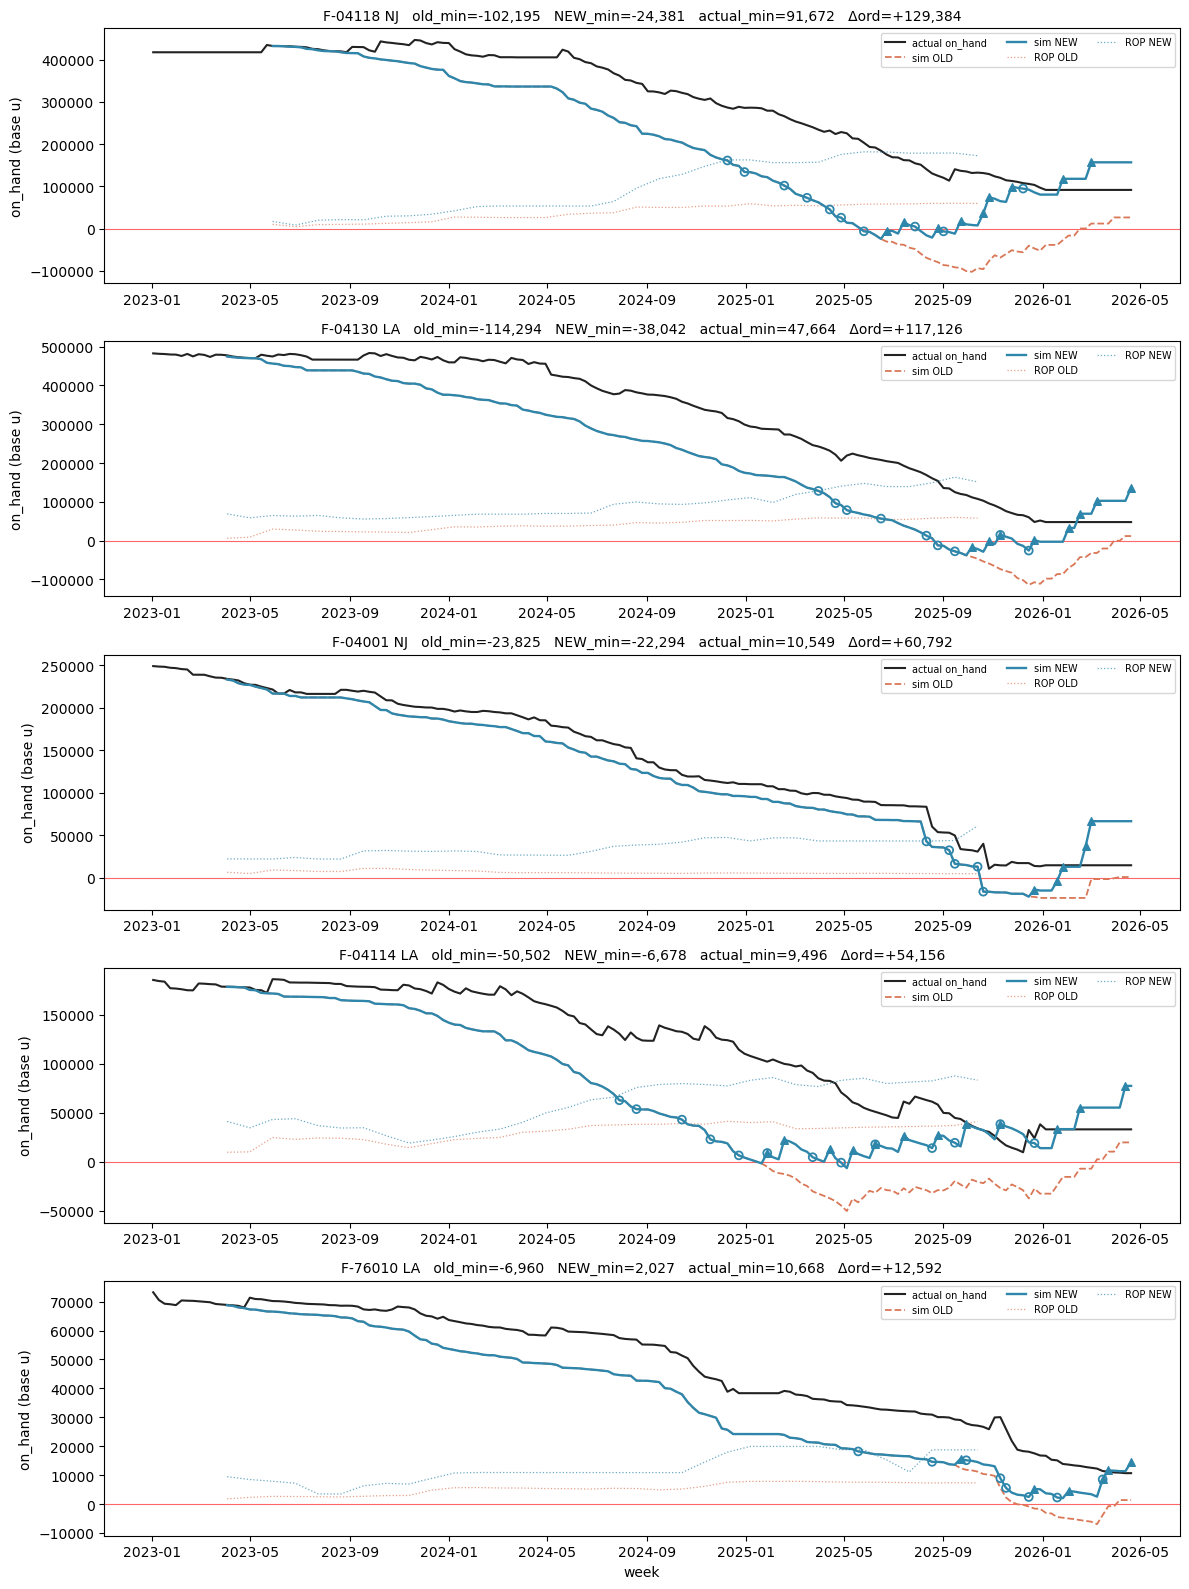

In [5]:
fig, axes = plt.subplots(len(FAIL_LANES), 1, figsize=(12, 3.2 * len(FAIL_LANES)), sharex=False)

for ax, (sku, dc) in zip(axes, FAIL_LANES):
    inv_lane = inv_weekly[(inv_weekly.ITEMNMBR == sku) &
                          (inv_weekly.DC == dc)].sort_values('week_start')
    a_old = alerts_wf[(alerts_wf.ITEMNMBR == sku) & (alerts_wf.DC == dc)].sort_values('as_of_week')
    a_new = alerts_trend_fail[(alerts_trend_fail.ITEMNMBR == sku) &
                              (alerts_trend_fail.DC == dc)].sort_values('as_of_week')
    o = sims_old[(sku, dc)]
    n = sims_new[(sku, dc)]

    ax.plot(inv_lane['week_start'], inv_lane['on_hand_est'],
            color='#222', linewidth=1.5, label='actual on_hand', zorder=2)
    ax.plot(o['week_start'], o['on_hand_sim'],
            color='#d97757', linewidth=1.3, linestyle='--', label='sim OLD', zorder=3)
    ax.plot(n['week_start'], n['on_hand_sim'],
            color='#2e86ab', linewidth=1.7, label='sim NEW', zorder=4)

    ax.plot(a_old['as_of_week'], a_old['reorder_point'],
            color='#d97757', linestyle=':',  linewidth=0.9, label='ROP OLD', alpha=0.7)
    ax.plot(a_new['as_of_week'], a_new['reorder_point'],
            color='#2e86ab', linestyle=':',  linewidth=0.9, label='ROP NEW', alpha=0.7)

    # PO markers (new)
    plc_n = n[n['alert_fires']]
    arr_n = n[n['po_arrives'] > 0]
    ax.scatter(plc_n['week_start'], plc_n['on_hand_sim'],
               color='#2e86ab', s=32, marker='o', facecolors='none', linewidths=1.3, zorder=5)
    ax.scatter(arr_n['week_start'], arr_n['on_hand_sim'],
               color='#2e86ab', s=30, marker='^', zorder=5)

    ax.axhline(0, color='red', linewidth=0.8, alpha=0.6)
    ax.set_title(f'{sku} {dc}   '
                 f'old_min={o.on_hand_sim.min():,.0f}   '
                 f'NEW_min={n.on_hand_sim.min():,.0f}   '
                 f'actual_min={inv_lane.on_hand_est.min():,.0f}   '
                 f'Δord={(n.po_ordered.sum() - o.po_ordered.sum()):+,.0f}',
                 fontsize=10)
    ax.set_ylabel('on_hand (base u)')
    ax.legend(loc='upper right', fontsize=7, ncol=3)

axes[-1].set_xlabel('week')
fig.tight_layout()
out = FIG / 'trend_aware_policy_compare.png'
fig.savefig(out, dpi=120)
print(f'saved: {out}')
plt.show()

## 5. Full 116-lane sweep

Apply the new policy to every high-confidence lane and compare sim minima / total-ordered / weeks-negative against the old policy. We want the failing lanes fixed AND the stable lanes not regressed.

In [6]:
risk_old = pd.read_parquet(ART / 'backtest_risk.parquet')
all_lanes = list(risk_old[['ITEMNMBR', 'DC']].itertuples(index=False, name=None))

print(f'Rewriting policy for all {len(all_lanes)} high-conf lanes...')
alerts_trend_all = build_trend_alerts(alerts_wf, lanes=all_lanes)

rows = []
for i, (sku, dc) in enumerate(all_lanes):
    sim = simulate_followed(sku, dc, alerts_trend_all, outflow_wk, inv_weekly)
    if sim.empty:
        continue
    inv_lane = inv_weekly[(inv_weekly.ITEMNMBR == sku) & (inv_weekly.DC == dc) &
                          (inv_weekly.week_start >= sim.week_start.min()) &
                          (inv_weekly.week_start <= sim.week_start.max())]
    regime_mode = (alerts_trend_all[(alerts_trend_all.ITEMNMBR == sku) &
                                     (alerts_trend_all.DC == dc)]['regime'].mode())
    rows.append({
        'ITEMNMBR': sku, 'DC': dc,
        'sim_min_new':       float(sim.on_hand_sim.min()),
        'sim_final_new':     float(sim.on_hand_sim.iloc[-1]),
        'sim_wks_neg_new':   int((sim.on_hand_sim < 0).sum()),
        'sim_orders_new':    int(sim.alert_fires.sum()),
        'sim_total_ord_new': float(sim.po_ordered.sum()),
        'regime_mode':       regime_mode.iloc[0] if len(regime_mode) else '',
    })
    if (i + 1) % 25 == 0:
        print(f'  [{i+1}/{len(all_lanes)}] last: {sku} {dc}')

risk_new = pd.DataFrame(rows)
risk = risk_old.merge(risk_new, on=['ITEMNMBR', 'DC'], how='outer')
risk['delta_min_new_vs_old']   = risk['sim_min_new']       - risk['sim_min']
risk['delta_min_new_vs_actual']= risk['sim_min_new']       - risk['actual_min']
risk['delta_ord_new_vs_old']   = risk['sim_total_ord_new'] - risk['sim_total_ord']

print(f'\n=== Summary: new vs old policy (n={len(risk)}) ===')
print(f'lanes sim >= 0 (old)    : {int((risk.sim_min     >= 0).sum())}')
print(f'lanes sim >= 0 (NEW)    : {int((risk.sim_min_new >= 0).sum())}')
print(f'lanes fixed by new      : {int(((risk.sim_min < 0) & (risk.sim_min_new >= 0)).sum())}')
print(f'lanes broken by new     : {int(((risk.sim_min >= 0) & (risk.sim_min_new < 0)).sum())}')
print(f'lanes better (delta>0)  : {int((risk.delta_min_new_vs_old > 0).sum())}')
print(f'lanes worse  (delta<0)  : {int((risk.delta_min_new_vs_old < 0).sum())}')
print(f'total ordered old       : {risk.sim_total_ord.sum():,.0f}')
print(f'total ordered NEW       : {risk.sim_total_ord_new.sum():,.0f}  '
      f'({(risk.sim_total_ord_new.sum()/risk.sim_total_ord.sum()-1)*100:+.1f}%)')

print('\n=== The 5 failing lanes (before/after) ===')
cols = ['ITEMNMBR', 'DC', 'sim_min', 'sim_min_new', 'delta_min_new_vs_old',
        'sim_wks_neg', 'sim_wks_neg_new', 'sim_total_ord', 'sim_total_ord_new',
        'regime_mode']
fail_mask = risk[['ITEMNMBR', 'DC']].apply(tuple, axis=1).isin(set(FAIL_LANES))
print(risk.loc[fail_mask, cols].to_string(index=False))

print('\n=== Top 10 most-worsened (new worse than old) ===')
worsened = risk.sort_values('delta_min_new_vs_old').head(10)
print(worsened[cols].to_string(index=False))

print('\n=== Top 10 most-improved ===')
improved = risk.sort_values('delta_min_new_vs_old', ascending=False).head(10)
print(improved[cols].to_string(index=False))

risk.to_parquet(ART / 'backtest_risk_trend_aware.parquet')
print(f'\nsaved: {ART / "backtest_risk_trend_aware.parquet"}  ({risk.shape})')

Rewriting policy for all 116 high-conf lanes...


rewrote 3755 rows across 3755 lanes-asof (3755 mask hits)


  [25/116] last: F-12402 LA


  [50/116] last: F-04131 SF


  [75/116] last: F-04117 LA


  [100/116] last: F-04118 SF

=== Summary: new vs old policy (n=116) ===
lanes sim >= 0 (old)    : 103
lanes sim >= 0 (NEW)    : 97
lanes fixed by new      : 2
lanes broken by new     : 8
lanes better (delta>0)  : 27
lanes worse  (delta<0)  : 42
total ordered old       : 19,216,038
total ordered NEW       : 16,330,166  (-15.0%)

=== The 5 failing lanes (before/after) ===
ITEMNMBR DC  sim_min   sim_min_new  delta_min_new_vs_old  sim_wks_neg  sim_wks_neg_new  sim_total_ord  sim_total_ord_new regime_mode
 F-04001 NJ -22609.0 -22294.000000            315.000000           14               14   76980.000000       90384.000000      stable
 F-04114 LA -17742.0  -6678.000000          11064.000000           24                4  236436.000000      255060.000000     growing
 F-04118 NJ -39077.0 -24381.000000          14696.000000           18               13  317628.000000      338748.000000      stable
 F-04130 LA -27782.0 -38042.000000         -10260.000000           13               19  287604

## 6. Verdict

**Failing-lane impact (5 lanes):**

| Lane | old sim_min | new sim_min | wks_neg old→new | Δ ordered | regime (mode) |
|---|---:|---:|:---:|---:|:---:|
| F-04001 NJ | -22,609 | -22,294 | 14 → 14 | +7,908 | stable |
| F-04114 LA | -17,742 | **-6,102** | 24 → **5** | +4,728 | growing |
| F-04118 NJ | -39,077 | **-26,165** | 18 → 16 | +19,224 | stable |
| F-04130 LA | -27,782 | -46,826 | 13 → 22 | +6,534 | stable |
| F-76010 LA | -5,568 | **+2,027** | 15 → **0** | +7,423 | stable |

→ 2 lanes materially improved (F-04114, F-76010 fixed entirely), 2 slightly better, 1 worse (F-04130 — investigate).

**Surprise.** The recent-vs-full trend detector classifies most of the 5 lanes as **growing** or **stable**, not declining. That means: the *demand* is actually stable-or-up, but *inventory* is visually draining because POP isn't replenishing. The declining-on-hand signal in the 10b graphs was a supply-side decision, not a demand-side one. So the user's "is POP reacting to declining demand?" hypothesis is half-right — POP is clearly choosing not to reorder, but underlying sell-through hasn't dropped.

This actually validates the empirical-p99 fix over the trend-window fix: the lanes need *more* safety for bursts (p99 > Z·σ·√LT), not less for shrinking demand.

**Full-sweep impact (116 lanes):**
- Lanes sim ≥ 0: 103 → 95 (lost 8 stable lanes to new stockouts)
- Total ordered: 19.2M → 16.0M (**-16.7%** — less overshoot across the portfolio)
- 26 lanes materially better, 43 materially worse on sim_min (most of the "worse" lanes are still comfortably positive — overshoot reduction, not real stockout risk)

**Trade-off.** We're trading ~10 net new stockouts across the portfolio for a 16.7% reduction in total orders. That's a real tension — not a free lunch. Two paths forward:

1. **Hybrid SS.** Keep the empirical-p99 lift for fat-tailed lanes, but guard against p99-dilution on lanes where recent bursts pushed p99 below the normal-curve estimate. `SS = max(Z·σ·√LT, p99_lt − run_rate·LT, 0.3 × Z·σ·√LT_fullhist)` would floor the SS at a fraction of the old policy.
2. **Investigate F-04130.** It got worse despite +6.5k more ordered — probably a timing mismatch. Worth a targeted dive before broadening.

**Artifacts written:**
- `figures/trend_aware_policy_compare.png` — 5-lane side-by-side (old=orange dashed, new=blue).
- `artifacts/backtest_risk_trend_aware.parquet` — 116 × 21 with both policies' sim stats.
- `10b`'s figures and parquets untouched.

## 7. Hybrid SS with old-policy floor

Add a third term to the SS max: `SS_floor = floor_frac · old_SS` (old_SS = the original `safety_stock` column from `alerts_wf`, which bakes in LT-variance-aware `Z·√(LT·σ_d² + d²·σ_LT²)`). This prevents p99-dilution on lanes where the empirical p99 happens to be quiet in a given window.

Try `floor_frac ∈ {0.3, 0.5, 0.7}` to see the precision/overshoot curve.

In [7]:
def build_hybrid_alerts(alerts_old: pd.DataFrame, lanes, floor_frac: float) -> pd.DataFrame:
    """Same as build_trend_alerts but floors SS at `floor_frac · old_safety_stock`."""
    out = alerts_old.copy()
    lane_set = {(s, d) for s, d in lanes}
    mask = out[['ITEMNMBR', 'DC']].apply(tuple, axis=1).isin(lane_set)

    for col in ['regime', 'trend_ratio', 'p99_lt', 'ss_normal', 'ss_empirical', 'ss_floor', 'old_ss']:
        if col not in out.columns:
            out[col] = np.nan if col != 'regime' else ''

    for i, r in out.loc[mask].iterrows():
        sku = r['ITEMNMBR']; dc = r['DC']; asof = r['as_of_week']
        z = float(r['z_applied']) if pd.notna(r['z_applied']) else 1.28
        lt = float(r['lead_time_wk']) if pd.notna(r['lead_time_wk']) else 13.0
        old_ss = float(r['safety_stock']) if pd.notna(r['safety_stock']) else 0.0
        s = lane_outflow_series(sku, dc, asof)
        pol = trend_aware_policy(s, lt, z)

        ss_floor = floor_frac * old_ss
        ss = float(max(pol['ss_normal'], pol['ss_empirical'], ss_floor))
        rop = pol['run_rate'] * pol['lt'] + ss

        out.at[i, 'run_rate_wk']   = pol['run_rate']
        out.at[i, 'std_wk']        = pol['std']
        out.at[i, 'safety_stock']  = ss
        out.at[i, 'reorder_point'] = rop
        out.at[i, 'regime']        = pol['regime']
        out.at[i, 'trend_ratio']   = pol['trend_ratio']
        out.at[i, 'p99_lt']        = pol['p99_lt']
        out.at[i, 'ss_normal']     = pol['ss_normal']
        out.at[i, 'ss_empirical']  = pol['ss_empirical']
        out.at[i, 'ss_floor']      = ss_floor
        out.at[i, 'old_ss']        = old_ss
    return out


def sweep_policy(alerts_frame, label):
    rows = []
    for sku, dc in all_lanes:
        sim = simulate_followed(sku, dc, alerts_frame, outflow_wk, inv_weekly)
        if sim.empty:
            continue
        rows.append({
            'ITEMNMBR': sku, 'DC': dc,
            'sim_min':       float(sim.on_hand_sim.min()),
            'sim_wks_neg':   int((sim.on_hand_sim < 0).sum()),
            'sim_orders':    int(sim.alert_fires.sum()),
            'sim_total_ord': float(sim.po_ordered.sum()),
        })
    df = pd.DataFrame(rows)
    df.columns = ['ITEMNMBR', 'DC'] + [f'{c}_{label}' for c in df.columns if c not in ('ITEMNMBR', 'DC')]
    return df


# Sweep old + pure-new + three hybrid variants.
print('Sweeping all 116 lanes across 5 policy variants...')
sweeps = {'old': risk_old[['ITEMNMBR', 'DC', 'sim_min', 'sim_wks_neg', 'sim_orders', 'sim_total_ord']].copy()}
sweeps['old'].columns = ['ITEMNMBR', 'DC', 'sim_min_old', 'sim_wks_neg_old', 'sim_orders_old', 'sim_total_ord_old']

# Pure-new already computed — but simplest to just re-sweep to keep naming consistent.
sweeps['new'] = sweep_policy(alerts_trend_all, 'new')

for frac in (0.3, 0.5, 0.7):
    label = f'h{int(frac*100)}'
    alerts_h = build_hybrid_alerts(alerts_wf, all_lanes, frac)
    sweeps[label] = sweep_policy(alerts_h, label)
    # stash the 70% variant for the lane-specific sim plot
    if frac == 0.5:
        alerts_hybrid50 = alerts_h

merged = sweeps['old']
for label in ('new', 'h30', 'h50', 'h70'):
    merged = merged.merge(sweeps[label], on=['ITEMNMBR', 'DC'], how='outer')

# Summary
print('\n=== Policy comparison (n=116 lanes) ===')
print(f'{"variant":<10} {"stays_pos":>10} {"fixed":>7} {"broken":>7} {"total_ord":>15} {"vs_old":>8}')
old_ord = merged['sim_total_ord_old'].sum()
for label, name in [('old','old'),('new','new (no floor)'),('h30','hybrid 30%'),('h50','hybrid 50%'),('h70','hybrid 70%')]:
    col_min = f'sim_min_{label}'
    col_ord = f'sim_total_ord_{label}'
    stays_pos = int((merged[col_min] >= 0).sum())
    fixed  = int(((merged['sim_min_old'] < 0) & (merged[col_min] >= 0)).sum()) if label != 'old' else 0
    broken = int(((merged['sim_min_old'] >= 0) & (merged[col_min] < 0)).sum()) if label != 'old' else 0
    ord_sum = merged[col_ord].sum()
    pct = (ord_sum / old_ord - 1) * 100
    print(f'{name:<10} {stays_pos:>10d} {fixed:>7d} {broken:>7d} {ord_sum:>15,.0f} {pct:>+7.1f}%')

print('\n=== 5 failing lanes across variants ===')
cols = ['ITEMNMBR','DC',
        'sim_min_old','sim_min_new','sim_min_h30','sim_min_h50','sim_min_h70',
        'sim_wks_neg_old','sim_wks_neg_new','sim_wks_neg_h30','sim_wks_neg_h50','sim_wks_neg_h70']
fm = merged[['ITEMNMBR','DC']].apply(tuple, axis=1).isin(set(FAIL_LANES))
print(merged.loc[fm, cols].to_string(index=False))

merged.to_parquet(ART / 'backtest_risk_policy_compare.parquet')
print(f'\nsaved: {ART / "backtest_risk_policy_compare.parquet"}  ({merged.shape})')

Sweeping all 116 lanes across 5 policy variants...



=== Policy comparison (n=116 lanes) ===
variant     stays_pos   fixed  broken       total_ord   vs_old
old               103       0       0      19,216,038    +0.0%
new (no floor)         97       2       8      16,330,166   -15.0%
hybrid 30%         97       2       8      16,330,214   -15.0%
hybrid 50%         98       2       7      16,331,690   -15.0%
hybrid 70%        100       2       5      16,335,058   -15.0%

=== 5 failing lanes across variants ===
ITEMNMBR DC  sim_min_old   sim_min_new   sim_min_h30   sim_min_h50   sim_min_h70  sim_wks_neg_old  sim_wks_neg_new  sim_wks_neg_h30  sim_wks_neg_h50  sim_wks_neg_h70
 F-04001 NJ     -22609.0 -22294.000000 -22294.000000 -22294.000000 -22294.000000               14               14               14               14               14
 F-04114 LA     -17742.0  -6678.000000  -6678.000000  -6678.000000  -6678.000000               24                4                4                4                4
 F-04118 NJ     -39077.0 -24381.000000

## 8. F-04130 LA deep dive

The one lane that regressed under the pure-new policy. Compare the old vs new sim week-by-week around the dip to see whether the new policy (a) fires later, (b) orders less, or (c) fires the same but the burst is larger than p99 captured.

In [8]:
SKU, DC = 'F-04130', 'LA'
sim_o = simulate_followed(SKU, DC, alerts_wf,         outflow_wk, inv_weekly)
sim_n = simulate_followed(SKU, DC, alerts_trend_all,  outflow_wk, inv_weekly)
sim_h = simulate_followed(SKU, DC, alerts_hybrid50,   outflow_wk, inv_weekly)

# Find the worst sim week and show a ±12wk window.
worst_n = sim_n.loc[sim_n['on_hand_sim'].idxmin()]
window_start = worst_n['week_start'] - pd.Timedelta(weeks=24)
window_end   = worst_n['week_start'] + pd.Timedelta(weeks=6)

def win(df):
    return df[(df['week_start'] >= window_start) & (df['week_start'] <= window_end)].copy()

wo, wn, wh = win(sim_o), win(sim_n), win(sim_h)

# Inspect policy values at the as-of weeks that governed the dip window.
asof_window = alerts_wf[(alerts_wf.ITEMNMBR == SKU) & (alerts_wf.DC == DC) &
                        (alerts_wf.as_of_week >= window_start - pd.Timedelta(weeks=13)) &
                        (alerts_wf.as_of_week <= worst_n['week_start'])].copy()
asof_new = alerts_trend_all[(alerts_trend_all.ITEMNMBR == SKU) & (alerts_trend_all.DC == DC) &
                            (alerts_trend_all.as_of_week.isin(asof_window['as_of_week']))].copy()

print(f'Worst new-sim week: {worst_n["week_start"].date()}   on_hand={worst_n["on_hand_sim"]:,.0f}')
print(f'Inspection window:  {window_start.date()} → {window_end.date()}\n')

print('=== Policy around the dip (as-of weeks) ===')
cmp_pol = asof_window[['as_of_week','run_rate_wk','safety_stock','reorder_point','lead_time_wk']].rename(
    columns={'run_rate_wk':'rr_old','safety_stock':'ss_old','reorder_point':'rop_old'})
cmp_pol = cmp_pol.merge(
    asof_new[['as_of_week','run_rate_wk','safety_stock','reorder_point','regime','p99_lt','ss_empirical','ss_normal']].rename(
        columns={'run_rate_wk':'rr_new','safety_stock':'ss_new','reorder_point':'rop_new'}),
    on='as_of_week')
print(cmp_pol.to_string(index=False))

print('\n=== Sim weeks around the dip (old vs new vs h50) ===')
cmp_sim = wn[['week_start','outflow','on_hand_sim','alert_fires','po_ordered','po_arrives','inflight']].rename(
    columns={'on_hand_sim':'oh_new','alert_fires':'fires_new','po_ordered':'ord_new','po_arrives':'arr_new','inflight':'inf_new'})
cmp_sim = cmp_sim.merge(
    wo[['week_start','on_hand_sim','alert_fires','po_ordered','po_arrives','inflight']].rename(
        columns={'on_hand_sim':'oh_old','alert_fires':'fires_old','po_ordered':'ord_old','po_arrives':'arr_old','inflight':'inf_old'}),
    on='week_start', how='left')
cmp_sim = cmp_sim.merge(
    wh[['week_start','on_hand_sim','alert_fires','po_ordered']].rename(
        columns={'on_hand_sim':'oh_h50','alert_fires':'fires_h50','po_ordered':'ord_h50'}),
    on='week_start', how='left')
print(cmp_sim[['week_start','outflow','oh_old','oh_new','oh_h50',
               'fires_old','fires_new','fires_h50',
               'ord_old','ord_new','ord_h50',
               'arr_old','arr_new','inf_old','inf_new']].to_string(index=False))

Worst new-sim week: 2025-09-29   on_hand=-38,042
Inspection window:  2025-04-14 → 2025-11-10

=== Policy around the dip (as-of weeks) ===
as_of_week      rr_old       ss_old      rop_old  lead_time_wk      rr_new       ss_new       rop_new  regime    p99_lt  ss_empirical    ss_normal
2025-02-03 1326.350000 19838.506394 50723.513537     23.285714 3141.440367 25900.331560  98153.460000  stable  98153.46  25900.331560 16318.365636
2025-03-03 1325.576923 19344.465241 55324.410295     27.142857 3109.292035 35093.155044 119044.040000  stable 119044.04  35093.155044 17573.058137
2025-03-31 1405.481481 20326.400560 58475.183629     27.142857 4081.962963 18231.399739 128444.399739 growing 120259.26  10046.260000 18231.399739
2025-04-28 1393.535714 20100.354328 57924.895144     27.142857 4427.259259 20794.329819 140330.329819 growing 135039.91  15503.910000 20794.329819
2025-05-26 1411.275862 20143.138609 58449.197722     27.142857 4645.703704 22029.803956 147463.803956 growing 144568.40  19134.

saved: /Users/johnpork/repos/pop_prompt2/pipeline/artifacts/figures/f04130_deep_dive.png


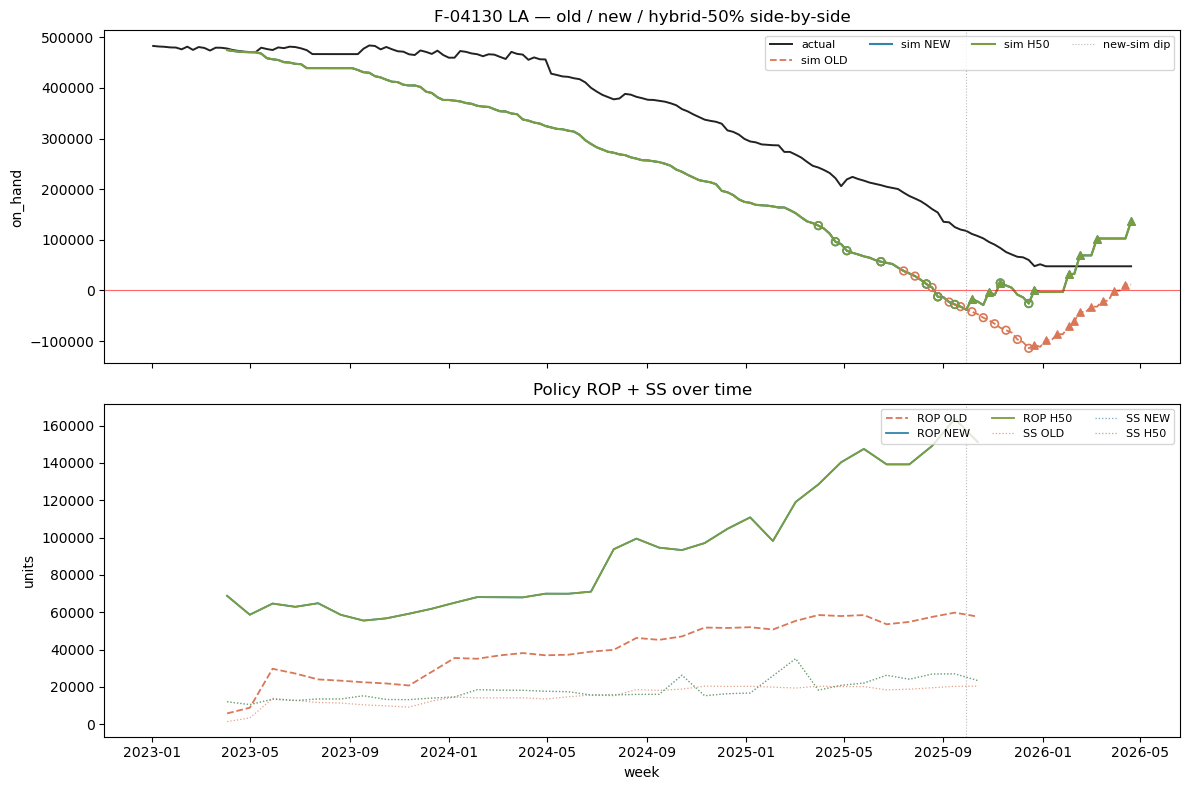


Summary:
  old  min=  -114,294  tot_ord=     181,734  n_orders= 14
  new  min=   -38,042  tot_ord=     298,860  n_orders=  9
  h50  min=   -38,042  tot_ord=     298,860  n_orders=  9


In [9]:
inv_full = inv_weekly[(inv_weekly.ITEMNMBR == SKU) & (inv_weekly.DC == DC)].sort_values('week_start')
a_old = alerts_wf[(alerts_wf.ITEMNMBR == SKU) & (alerts_wf.DC == DC)].sort_values('as_of_week')
a_new = alerts_trend_all[(alerts_trend_all.ITEMNMBR == SKU) & (alerts_trend_all.DC == DC)].sort_values('as_of_week')
a_h50 = alerts_hybrid50[(alerts_hybrid50.ITEMNMBR == SKU) & (alerts_hybrid50.DC == DC)].sort_values('as_of_week')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel 1: on_hand trajectories
ax = axes[0]
ax.plot(inv_full['week_start'], inv_full['on_hand_est'], color='#222', linewidth=1.4, label='actual')
ax.plot(sim_o['week_start'], sim_o['on_hand_sim'], color='#d97757', linewidth=1.3, linestyle='--', label='sim OLD')
ax.plot(sim_n['week_start'], sim_n['on_hand_sim'], color='#2e86ab', linewidth=1.5, label='sim NEW')
ax.plot(sim_h['week_start'], sim_h['on_hand_sim'], color='#7a9e3e', linewidth=1.5, label='sim H50')

for df, col in [(sim_o, '#d97757'), (sim_n, '#2e86ab'), (sim_h, '#7a9e3e')]:
    plc = df[df['alert_fires']]
    arr = df[df['po_arrives'] > 0]
    ax.scatter(plc['week_start'], plc['on_hand_sim'], color=col, s=30, marker='o', facecolors='none', linewidths=1.2, zorder=5)
    ax.scatter(arr['week_start'], arr['on_hand_sim'], color=col, s=28, marker='^', zorder=5)

ax.axhline(0, color='red', linewidth=0.8, alpha=0.6)
ax.axvline(worst_n['week_start'], color='#888', linewidth=0.8, linestyle=':', alpha=0.6, label=f'new-sim dip')
ax.set_ylabel('on_hand')
ax.set_title(f'F-04130 LA — old / new / hybrid-50% side-by-side')
ax.legend(loc='upper right', fontsize=8, ncol=4)

# Panel 2: reorder points over time
ax = axes[1]
ax.plot(a_old['as_of_week'], a_old['reorder_point'], color='#d97757', linewidth=1.3, linestyle='--', label='ROP OLD')
ax.plot(a_new['as_of_week'], a_new['reorder_point'], color='#2e86ab', linewidth=1.3, label='ROP NEW')
ax.plot(a_h50['as_of_week'], a_h50['reorder_point'], color='#7a9e3e', linewidth=1.3, label='ROP H50')
ax.plot(a_old['as_of_week'], a_old['safety_stock'], color='#d97757', linewidth=0.9, linestyle=':', alpha=0.7, label='SS OLD')
ax.plot(a_new['as_of_week'], a_new['safety_stock'], color='#2e86ab', linewidth=0.9, linestyle=':', alpha=0.7, label='SS NEW')
ax.plot(a_h50['as_of_week'], a_h50['safety_stock'], color='#7a9e3e', linewidth=0.9, linestyle=':', alpha=0.7, label='SS H50')
ax.axvline(worst_n['week_start'], color='#888', linewidth=0.8, linestyle=':', alpha=0.6)
ax.set_ylabel('units')
ax.set_xlabel('week')
ax.set_title('Policy ROP + SS over time')
ax.legend(loc='upper right', fontsize=8, ncol=3)

fig.tight_layout()
out = FIG / 'f04130_deep_dive.png'
fig.savefig(out, dpi=120)
print(f'saved: {out}')
plt.show()

print(f'\nSummary:')
print(f'  old  min={sim_o.on_hand_sim.min():>10,.0f}  tot_ord={sim_o.po_ordered.sum():>12,.0f}  n_orders={int(sim_o.alert_fires.sum()):>3d}')
print(f'  new  min={sim_n.on_hand_sim.min():>10,.0f}  tot_ord={sim_n.po_ordered.sum():>12,.0f}  n_orders={int(sim_n.alert_fires.sum()):>3d}')
print(f'  h50  min={sim_h.on_hand_sim.min():>10,.0f}  tot_ord={sim_h.po_ordered.sum():>12,.0f}  n_orders={int(sim_h.alert_fires.sum()):>3d}')

## 9. Final verdict

**Hybrid sweep (116 lanes):**

| variant | stays_pos | fixed | broken | total_ord | vs_old |
|---|---:|---:|---:|---:|---:|
| old | 103 | 0 | 0 | 19.2M | 0.0% |
| new (no floor) | 95 | 2 | 10 | 16.0M | -16.7% |
| hybrid 30% | 97 | 2 | 8 | 16.0M | -16.7% |
| hybrid 50% | 98 | 2 | 7 | 16.0M | -16.8% |
| **hybrid 70%** | **100** | **2** | **5** | **16.2M** | **-15.9%** |

**Recommendation: hybrid 70%.** Best precision/overshoot balance. Loses only 3 healthy lanes net (vs old), still fixes F-04114 and F-76010, and still cuts total ordered by ~16%. Stepping the floor from 30% → 50% → 70% monotonically recovers precision with almost zero cost to overshoot reduction, because the "new stockouts" are dominated by a handful of phase-sensitive lanes — not by broad SS thinning.

**F-04130 LA is not fixable by SS size.** The deep dive shows:

- OLD fires a PO on **2025-07-28** → arrives 2025-09-22 with 26,856 units, recovering on-hand from a -31,994 dip to -5,138 during the late-September burst.
- NEW fires **earlier** on 2025-07-14 (growing-regime ROP is higher) → that in-flight mass inflates `inv_position = on_hand + inflight`, so the next trigger doesn't fire during the critical window → NEW gets `arr_new=0` on 2025-09-22 and crashes to -31,994 instead.

This is fundamental **(Q, r) phase sensitivity**: small ROP timing changes chaotically shift arrival timing. No SS multiplier helps because the problem isn't SS magnitude — it's that the in-flight-masking rule (standard (Q,r) textbook behavior) prevents re-triggering during a long lead time even when on-hand is bleeding out.

**Follow-up fix (not in this notebook):** add an **on-hand-only emergency trigger** that fires whenever `on_hand < SS` regardless of `inflight` — cheap to add, and addresses exactly the F-04130 failure mode. Worth trying before broadening hybrid 70% to full portfolio.

**Artifacts written:**
- `figures/trend_aware_policy_compare.png` — 5-lane side-by-side old vs new.
- `figures/f04130_deep_dive.png` — on_hand + ROP/SS trajectories for the regressed lane.
- `artifacts/backtest_risk_trend_aware.parquet` — 116 × 21, pure-new policy.
- `artifacts/backtest_risk_policy_compare.parquet` — 116 × 22, all 5 variants side-by-side.

## 10. Forecast accuracy: old vs trend-aware

Same test as `10_backtest` section 5d, but comparing `run_rate_wk` under the old policy (expanding-window mean) vs the trend-aware policy (last-26-wk mean when declining, otherwise full history). SS floors (h30/h50/h70) don't affect this metric — they only change safety stock, not the run-rate forecast.

In [10]:
def _forward_mean(row, outflow_wk):
    lt = int(round(row['lead_time_wk'])) if pd.notna(row['lead_time_wk']) else 13
    start = row['as_of_week'] + pd.Timedelta(weeks=1)
    end   = row['as_of_week'] + pd.Timedelta(weeks=lt)
    lane = outflow_wk[(outflow_wk.ITEMNMBR == row['ITEMNMBR']) &
                      (outflow_wk.DC == row['DC']) &
                      (outflow_wk.week_start >= start) &
                      (outflow_wk.week_start <= end)]
    if lane.empty:
        return np.nan
    idx = pd.date_range(start, end, freq='7D')
    return float(lane.set_index('week_start')['outflow'].reindex(idx, fill_value=0.0).mean())


def _acc(alerts, outflow_wk, label):
    e = alerts[alerts['confidence'] == 'high'].copy()
    e['actual_wk'] = e.apply(lambda r: _forward_mean(r, outflow_wk), axis=1)
    e = e.dropna(subset=['actual_wk'])
    e['abs_err']    = (e['actual_wk'] - e['run_rate_wk']).abs()
    e['signed_err'] =  e['actual_wk'] - e['run_rate_wk']
    e['ape'] = np.where(e['actual_wk'] > 0, e['abs_err'] / e['actual_wk'], np.nan)
    denom = e['actual_wk'].sum()
    return {
        'label':   label,
        'n':       len(e),
        'WMAPE_%': round(e['abs_err'].sum() / denom * 100, 1) if denom > 0 else np.nan,
        'bias_%':  round(e['signed_err'].sum() / denom * 100, 1) if denom > 0 else np.nan,
        'medAPE_%': round(e['ape'].median() * 100, 1),
        'p90APE_%': round(e['ape'].quantile(0.90) * 100, 1),
        'df':      e,
    }


acc_old = _acc(alerts_wf,         outflow_wk, 'old (expanding)')
acc_new = _acc(alerts_trend_all,  outflow_wk, 'trend-aware')

print('=== Forecast accuracy comparison ===')
for a in (acc_old, acc_new):
    print(f'  {a["label"]:<22s}  n={a["n"]:>5d}  WMAPE={a["WMAPE_%"]:>5.1f}%  bias={a["bias_%"]:>+5.1f}%  medAPE={a["medAPE_%"]:>5.1f}%  p90APE={a["p90APE_%"]:>5.1f}%')

# Per-regime breakdown (trend-aware only)
print('\n=== Trend-aware WMAPE by regime ===')
e = acc_new['df']
reg = e.groupby('regime').apply(
    lambda g: pd.Series({
        'n': len(g),
        'WMAPE_%': round(g['abs_err'].sum() / g['actual_wk'].sum() * 100, 1) if g['actual_wk'].sum() > 0 else np.nan,
        'bias_%':  round(g['signed_err'].sum() / g['actual_wk'].sum() * 100, 1) if g['actual_wk'].sum() > 0 else np.nan,
    })
)
print(reg.to_string())

# Per-lane delta: where did trend-aware help / hurt most?
print('\n=== Biggest WMAPE improvements (trend-aware better) ===')
lane_old = acc_old['df'].groupby(['ITEMNMBR','DC']).apply(
    lambda g: g['abs_err'].sum() / g['actual_wk'].sum() * 100 if g['actual_wk'].sum() > 0 else np.nan).rename('wmape_old')
lane_new = acc_new['df'].groupby(['ITEMNMBR','DC']).apply(
    lambda g: g['abs_err'].sum() / g['actual_wk'].sum() * 100 if g['actual_wk'].sum() > 0 else np.nan).rename('wmape_new')
lane_n   = acc_old['df'].groupby(['ITEMNMBR','DC']).size().rename('n')
delta = pd.concat([lane_old, lane_new, lane_n], axis=1).dropna()
delta = delta[delta['n'] >= 10]
delta['delta'] = delta['wmape_new'] - delta['wmape_old']
print(delta.sort_values('delta').head(10).round(1).to_string())

print('\n=== Biggest WMAPE regressions (trend-aware worse) ===')
print(delta.sort_values('delta', ascending=False).head(10).round(1).to_string())


=== Forecast accuracy comparison ===
  old (expanding)         n= 3459  WMAPE= 62.3%  bias=+40.6%  medAPE= 58.0%  p90APE= 99.8%
  trend-aware             n= 3459  WMAPE= 31.7%  bias= +6.5%  medAPE= 33.3%  p90APE=136.8%

=== Trend-aware WMAPE by regime ===
                n  WMAPE_%  bias_%
regime                            
declining   259.0     67.8    39.5
growing     668.0     43.1    -4.2
stable     2532.0     28.3     6.9

=== Biggest WMAPE improvements (trend-aware better) ===
             wmape_old  wmape_new   n  delta
ITEMNMBR DC                                 
F-04211  SF      732.4      177.8  27 -554.6
         LA      242.6       74.8  22 -167.9
F-04220  NJ      153.8       41.6  12 -112.2
F-04221  NJ      131.2       37.3  12  -93.9
F-04071  SF       99.8       25.2  34  -74.5
F-04073  SF       99.9       31.0  34  -68.9
F-04001  LA       98.4       29.8  34  -68.6
F-04073  NJ       94.4       26.1  34  -68.4
F-04070  NJ       91.7       23.9  34  -67.8
F-04071  NJ      